In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.sparse.linalg import eigsh, ArpackNoConvergence
from scipy.optimize import minimize_scalar
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import sqoct_core as sq

In [2]:
t1 = 1.0
Delta = 0.20

Nx = 10
Ny = 6

eta = 1e-8
Jmax = 4.5

In [3]:
def build_system(t2):

    syst = kwant.Builder()

    T1 = sq.hopping_bdg(t1)
    T2 = sq.hopping_bdg(t2)

    # all sites first
    for ix in range(Nx):
        for iy in range(Ny):

            syst[sq.A(ix, iy)] = sq.onsite_clean
            syst[sq.B(ix, iy)] = sq.onsite_clean
            syst[sq.C(ix, iy)] = sq.onsite_clean
            syst[sq.D(ix, iy)] = sq.onsite_clean

    # Magnetic impurity at the central A site
    impurity = sq.A( Nx // 2, Ny // 2)

    syst[impurity] = sq.onsite_impurity

    # hoppings
    for ix in range(Nx):
        for iy in range(Ny):

            # Square edges
            syst[sq.A(ix, iy), sq.B(ix, iy)] = T1
            syst[sq.B(ix, iy), sq.C(ix, iy)] = T1
            syst[sq.C(ix, iy), sq.D(ix, iy)] = T1
            syst[sq.D(ix, iy), sq.A(ix, iy)] = T1

            # Diagonal hoppings
            syst[sq.A(ix, iy), sq.C(ix, iy)] = T2
            syst[sq.B(ix, iy), sq.D(ix, iy)] = T2

            # Periodic boundary conditions
            syst[sq.C(ix, iy), sq.A(ix, (iy + 1) % Ny)] = T1

            syst[sq.B(ix, iy), sq.D((ix + 1) % Nx, iy)] = T1

    fsyst = syst.finalized()

    impurity_index = fsyst.id_by_site[impurity]

    return fsyst, impurity_index

In [4]:
t2 = 1.0
mu = 0.0

J_values = np.linspace(0.0, 1.30, 91)

fsyst, imp_idx = build_system(t2=t2)


# Critical coupling from the zero-energy Green function
Gii = sq.local_clean_green(
    fsyst, imp_idx,
    mu=mu, Delta=Delta,
    E=0.0, eta=eta
)

Jc, _ = sq.Jc_from_green(
    Gii,
    Jmax=1.5, nscan=1601
)


# YSR energy
E_ysr = sq.scan_ysr_vs_J(
    fsyst, J_values,
    mu=mu, Delta=Delta
)


print("Jc =", Jc)

Jc = 0.7208383877086895


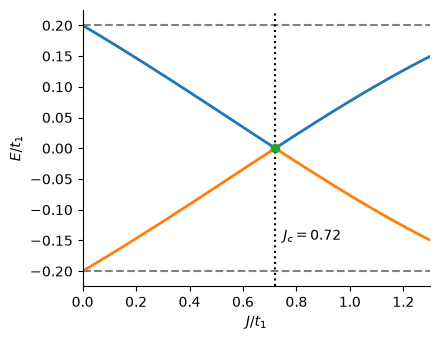

In [5]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))

ax.plot(J_values, E_ysr, lw=2)
ax.plot(J_values, -E_ysr, lw=2)

# Superconducting gap
ax.axhline(Delta, color="gray", ls="--")
ax.axhline(-Delta, color="gray", ls="--")

# YSR zero-energy crossing
ax.axvline(Jc, color="black", ls=":")
ax.plot(Jc, 0, "o")

ax.text(
    Jc + 0.03, -0.15,
    rf"$J_c={Jc:.2f}$"
)

ax.set_xlabel(r"$J/t_1$")
ax.set_ylabel(r"$E/t_1$")

ax.set_xlim(0, 1.30)
ax.set_ylim(-0.225, 0.225)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# plt.savefig(
#     "figures/ysr_spectrum.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [6]:
def reduced_Jc(Gii):

    # Reduced (c_up, c_down^dagger) sector
    G = Gii[np.ix_([0, 3], [0, 3])]

    G = 0.5 * (G + G.conj().T)

    ge = G[0, 0].real
    gh = G[1, 1].real
    f = G[0, 1]

    gbar = 0.5 * (ge + gh)
    dg = 0.5 * (ge - gh)

    lambda_plus = gbar + np.sqrt(dg**2 + np.abs(f)**2)

    if lambda_plus <= 0:
        return np.nan

    return 1.0 / lambda_plus


def min_bdg_energy(fsyst, J, mu):

    H = fsyst.hamiltonian_submatrix(
        sparse=True,
        params={"J": J, "mu": mu, "Delta": Delta}
    )

    try:
        evals = eigsh(
            H, k=6, sigma=1e-8, which="LM",
            return_eigenvectors=False,
            ncv=40, maxiter=150000, tol=1e-10
        )

    except ArpackNoConvergence:
        evals = np.linalg.eigvalsh(H.toarray())

    return np.min(np.abs(evals))


def direct_bdg_Jc(fsyst, mu, J_guess):

    width = max(0.30, 0.25 * J_guess)

    result = minimize_scalar(
        lambda J: min_bdg_energy(fsyst, J, mu),
        bounds=(
            max(0, J_guess - width),
            min(Jmax, J_guess + width)
        ),
        method="bounded",
        options={"xatol": 1e-4}
    )

    return result.x

In [7]:
t2_values = [0.20, 0.50, 0.75, 1.00]

mu_values = np.arange(-1.30, 1.201, 0.05)


# Sparse points used for direct BdG
mu_bdg = np.array([
    -1.10, -0.80, -0.50, -0.20,
     0.20,  0.60,  1.00
])

In [8]:
Jc_full = {}
Jc_reduced = {}


for t2 in t2_values:

    print("t2/t1 =", t2)

    fsyst, imp_idx = build_system(t2=t2)

    full_values = []
    reduced_values = []

    for mu in mu_values:

        Gii = sq.local_clean_green(
            fsyst, imp_idx,
            mu=mu, Delta=Delta,
            E=0.0, eta=eta
        )

        # Full Green-function pole
        Jgf, _ = sq.Jc_from_green(
            Gii, Jmax=Jmax, nscan=801
        )

        if np.isfinite(Jgf) and Jgf < 0.995 * Jmax:
            full_values.append(Jgf)
        else:
            full_values.append(np.nan)

        # Reduced Green-function expression
        Jred = reduced_Jc(Gii)

        if np.isfinite(Jred) and Jred < Jmax:
            reduced_values.append(Jred)
        else:
            reduced_values.append(np.nan)

    Jc_full[t2] = np.array(full_values)
    Jc_reduced[t2] = np.array(reduced_values)

t2/t1 = 0.2
t2/t1 = 0.5
t2/t1 = 0.75
t2/t1 = 1.0


In [9]:
Jc_bdg = {}


for t2 in t2_values:

    print("BdG: t2/t1 =", t2)

    fsyst, imp_idx = build_system(t2=t2)

    values = []

    for mu in mu_bdg:

        # Green-function value used only as initial guess
        Gii = sq.local_clean_green(
            fsyst, imp_idx,
            mu=mu, Delta=Delta,
            E=0.0, eta=eta
        )

        J_guess, _ = sq.Jc_from_green(
            Gii, Jmax=Jmaxhttps://github.com/Ravieroy/square-octagon-ysr-transport, nscan=1201
        )

        if np.isfinite(J_guess) and J_guess < 0.995 * Jmax:
            Jbdg = direct_bdg_Jc(fsyst, mu, J_guess)
        else:
            Jbdg = np.nan

        values.append(Jbdg)

    Jc_bdg[t2] = np.array(values)

BdG: t2/t1 = 0.2
BdG: t2/t1 = 0.5
BdG: t2/t1 = 0.75
BdG: t2/t1 = 1.0


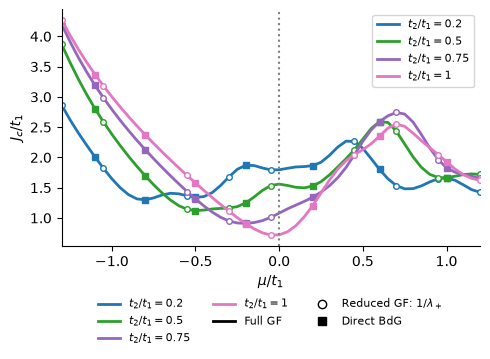

In [10]:
fig, ax = plt.subplots(figsize=(5.0, 3.8))


for t2 in t2_values:

    # Full Green-function result
    line, = ax.plot(
        mu_values, Jc_full[t2],
        lw=2, label=rf"$t_2/t_1={t2:g}$"
    )

    color = line.get_color()

    # Reduced Green-function result
    inds = np.arange(0, len(mu_values), 5)
    valid = np.isfinite(Jc_reduced[t2][inds])

    ax.plot(
        mu_values[inds][valid], Jc_reduced[t2][inds][valid],
        "o", ms=4, mfc="white", mec=color, linestyle="none"
    )

    # Direct BdG result
    valid = np.isfinite(Jc_bdg[t2])

    ax.plot(
        mu_bdg[valid], Jc_bdg[t2][valid],
        "s", ms=4, color=color, linestyle="none"
    )


ax.axvline(0, color="gray", ls=":")

ax.set_xlabel(r"$\mu/t_1$")
ax.set_ylabel(r"$J_c/t_1$")
ax.set_xlim(mu_values[0], mu_values[-1])


# Legend for t2
legend1 = ax.legend(loc="upper right", fontsize=8)
ax.add_artist(legend1)


# Simple dummy points for method legend
ax.plot([], [], color="black", lw=2, label="Full GF")

ax.plot(
    [], [], "o",
    mfc="white", mec="black",
    label=r"Reduced GF: $1/\lambda_+$"
)

ax.plot([], [], "s", color="black", label="Direct BdG")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3, fontsize=8, frameon=False
)


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# plt.savefig(
#     "figures/Jc_vs_mu.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [11]:
t2_min_values = np.array([
    0.00, 0.20, 0.40,
    0.60, 0.80, 1.00
])

mu_min_values = np.arange(-1.30, 0.301, 0.025)

In [12]:
Jc_min = []
mu_at_min = []


for t2 in t2_min_values:

    print("t2/t1 =", t2)

    fsyst, imp_idx = build_system(t2=t2)

    J_values = []

    for mu in mu_min_values:

        Gii = sq.local_clean_green(
            fsyst, imp_idx,
            mu=mu, Delta=Delta,
            E=0.0, eta=eta
        )

        Jc, _ = sq.Jc_from_green(
            Gii, Jmax=Jmax, nscan=801
        )

        if np.isfinite(Jc) and Jc < 0.995 * Jmax:
            J_values.append(Jc)
        else:
            J_values.append(np.nan)

    J_values = np.array(J_values)

    valid = np.isfinite(J_values)

    if np.any(valid):

        indices = np.where(valid)[0]

        index = indices[
            np.argmin(J_values[valid])
        ]

        Jc_min.append(J_values[index])
        mu_at_min.append(mu_min_values[index])

        print(
            "   Jc_min =", J_values[index],
            "mu_min =", mu_min_values[index]
        )

    else:

        Jc_min.append(np.nan)
        mu_at_min.append(np.nan)


Jc_min = np.array(Jc_min)
mu_at_min = np.array(mu_at_min)

t2/t1 = 0.0
   Jc_min = 1.3550874108888875 mu_min = -1.025000000000001
t2/t1 = 0.2
   Jc_min = 1.2998181008237109 mu_min = -0.8000000000000018
t2/t1 = 0.4
   Jc_min = 1.1871928724323733 mu_min = -0.6000000000000025
t2/t1 = 0.6
   Jc_min = 1.0452737645147632 mu_min = -0.37500000000000333
t2/t1 = 0.8
   Jc_min = 0.861511812225153 mu_min = -0.15000000000000413
t2/t1 = 1.0
   Jc_min = 0.7136010753552542 mu_min = -0.025000000000004574


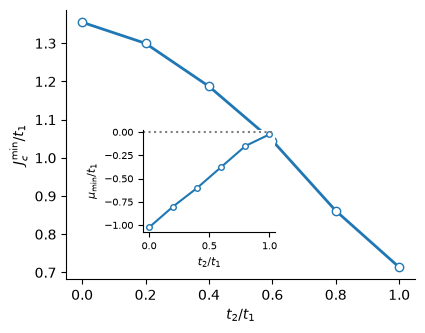

In [13]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(
    t2_min_values, Jc_min,
    "o-", lw=2, mfc="white"
)

ax.set_xlabel(r"$t_2/t_1$")
ax.set_ylabel(r"$J_c^{\rm min}/t_1$")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# Inset: chemical potential where the minimum occurs
axins = inset_axes(
    ax, width="38%", height="38%",
    loc="lower left",
    bbox_to_anchor=(0.20, 0.15, 1, 1),
    bbox_transform=ax.transAxes
)

axins.plot(
    t2_min_values, mu_at_min,
    "o-", lw=1.5, ms=4, mfc="white"
)

axins.axhline(0, color="gray", ls=":")

axins.set_xlabel(r"$t_2/t_1$", fontsize=8)
axins.set_ylabel(r"$\mu_{\rm min}/t_1$", fontsize=8)

axins.tick_params(labelsize=7)

axins.spines["top"].set_visible(False)
axins.spines["right"].set_visible(False)

# plt.savefig(
#     "figures/Jc_min_vs_t2.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()